# 12 — Fine-Tuning for Classification: Spam Detection

**Lecture goal:** understand what fine-tuning is and why it's so much cheaper than pretraining, then adapt our pretrained GPT-2 (notebook 11) into a working spam/ham text classifier by replacing its output layer and training just a small fraction of its weights.

## Pretraining vs. fine-tuning

Notebook 10 (pretraining from scratch) and notebook 11 (loading OpenAI's weights) both produced a model that does exactly one thing: **predict the next token**, given everything before it. That's an extremely general skill, but it isn't directly "classify this message as spam or not."

**Fine-tuning** takes a model that's already pretrained and continues training it — usually much more briefly, and on a much smaller, task-specific labeled dataset — to specialize it for a concrete downstream task. Because the pretrained weights already encode a huge amount of general language understanding (grammar, common word associations, world knowledge picked up from its original training data), fine-tuning typically needs only a small dataset (thousands, not billions, of examples) and modest compute (minutes, not weeks) to reach strong performance — we're adapting existing knowledge, not building it from nothing.

There are two broad flavors: **classification fine-tuning** (today — the model chooses among a small, fixed set of labels) and **instruction fine-tuning** (notebook 13 — the model learns to follow open-ended natural-language instructions). Today's task: given an SMS text message, decide whether it's `spam` or `ham` (not spam).

## The dataset: SMS Spam Collection

A small, well-known public dataset from the UCI Machine Learning Repository: 5,574 real SMS messages, each labeled `spam` or `ham`. We download and unzip it directly (it's small, about 200KB).

In [1]:
import urllib.request
import zipfile
import io
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
response_data = urllib.request.urlopen(request, timeout=30).read()

with zipfile.ZipFile(io.BytesIO(response_data)) as zf:
    with zf.open("SMSSpamCollection") as f:
        lines = f.read().decode("utf-8").splitlines()

rows = [line.split("\t", 1) for line in lines]
df = pd.DataFrame(rows, columns=["label", "text"])
print(df.shape)
print(df["label"].value_counts())
df.head()

(5574, 2)
label
ham     4827
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Balancing the classes

Notice the imbalance: 4,827 `ham` messages but only 747 `spam` ones. If we trained on this as-is, a model could reach ~87% accuracy by *always* predicting `"ham"` and never actually learning anything about what spam looks like — accuracy alone would badly mislead us about whether real learning happened. The standard fix: **downsample** the majority class (`ham`) to match the minority class (`spam`) count, so the training signal is balanced between the two.

In [2]:
spam_df = df[df["label"] == "spam"]
ham_df = df[df["label"] == "ham"].sample(len(spam_df), random_state=123)

balanced_df = pd.concat([spam_df, ham_df]).sample(frac=1, random_state=123).reset_index(drop=True)
balanced_df["label"] = balanced_df["label"].map({"ham": 0, "spam": 1})

print(balanced_df.shape)
print(balanced_df["label"].value_counts())

(1494, 2)
label
1    747
0    747
Name: count, dtype: int64


In [3]:
n = len(balanced_df)
train_df = balanced_df.iloc[: int(0.7 * n)].reset_index(drop=True)
val_df = balanced_df.iloc[int(0.7 * n): int(0.8 * n)].reset_index(drop=True)
test_df = balanced_df.iloc[int(0.8 * n):].reset_index(drop=True)

print("train:", len(train_df), " val:", len(val_df), " test:", len(test_df))

train: 1045  val: 150  test: 299


## Turning messages into fixed-length batches

Notebook 03's `Dataset` sliced one long, continuous document into equal-length chunks via a sliding window. Here, each SMS message is its own short, independent example, and messages naturally have different lengths — but a batch tensor requires every example in it to have the *same* length. The fix: **padding**. We tokenize every message, find the longest one (in the training set), and pad every shorter message out to that same length using a filler token — we reuse the `<|endoftext|>` token (ID `50256`) for this, appended as many times as needed after the real content.

One subtlety worth calling out explicitly: for classification, we're going to use only the model's hidden state at the **very last token position** as a summary of the whole message (more on why below) — and thanks to *causal* attention (notebook 06), that last position — even though it's literally a padding token — has still attended to every real token that came before it. Its hidden state still meaningfully summarizes the entire real message, padding or not.

In [4]:
import torch
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")
PAD_TOKEN_ID = 50256

max_length = max(len(tokenizer.encode(text)) for text in train_df["text"])
print("Longest message in the training set, in tokens:", max_length)


class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, pad_token_id=PAD_TOKEN_ID):
        self.labels = df["label"].tolist()
        encoded = [tokenizer.encode(text) for text in df["text"]]
        encoded = [ids[:max_length] for ids in encoded]  # truncate anything longer than max_length
        self.encoded = [ids + [pad_token_id] * (max_length - len(ids)) for ids in encoded]  # pad the rest

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded[idx]), torch.tensor(self.labels[idx])


train_dataset = SpamDataset(train_df, tokenizer, max_length)
val_dataset = SpamDataset(val_df, tokenizer, max_length)
test_dataset = SpamDataset(test_df, tokenizer, max_length)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Batches — train:", len(train_loader), " val:", len(val_loader), " test:", len(test_loader))

Longest message in the training set, in tokens: 132
Batches — train: 130  val: 19  test: 38


## Loading the pretrained model (exactly as in notebook 11)

In [5]:
import torch.nn as nn
from transformers import GPT2Model


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape
        queries = self.W_query(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.W_key(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.W_value(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attention_weights = torch.softmax(attention_scores / self.head_dim ** 0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)
        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)
        return self.out_proj(context_vectors)


class LayerNorm(nn.Module):
    def __init__(self, embedding_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized + self.shift


class FeedForward(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim), nn.GELU(), nn.Linear(4 * embedding_dim, embedding_dim)
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=cfg["embedding_dim"], d_out=cfg["embedding_dim"], context_length=cfg["context_length"],
            dropout=cfg["dropout_rate"], num_heads=cfg["num_heads"], qkv_bias=cfg["qkv_bias"],
        )
        self.feed_forward = FeedForward(cfg["embedding_dim"])
        self.norm1 = LayerNorm(cfg["embedding_dim"])
        self.norm2 = LayerNorm(cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = self.dropout(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["embedding_dim"])
        self.position_embedding = nn.Embedding(cfg["context_length"], cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])
        self.transformer_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["num_layers"])])
        self.final_norm = LayerNorm(cfg["embedding_dim"])
        self.out_head = nn.Linear(cfg["embedding_dim"], cfg["vocab_size"], bias=False)

    def forward(self, token_ids):
        batch_size, num_tokens = token_ids.shape
        token_embeds = self.token_embedding(token_ids)
        positions = torch.arange(num_tokens, device=token_ids.device)
        pos_embeds = self.position_embedding(positions)
        x = self.dropout(token_embeds + pos_embeds)
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


GPT_CONFIG_124M = {
    "vocab_size": 50257, "context_length": 1024, "embedding_dim": 768,
    "num_heads": 12, "num_layers": 12, "dropout_rate": 0.1, "qkv_bias": True,
}


def assign(target_param, source_tensor, name=""):
    if target_param.shape != source_tensor.shape:
        raise ValueError(f"Shape mismatch for {name}: {target_param.shape} vs {source_tensor.shape}")
    return nn.Parameter(source_tensor.clone().detach())


hf_model = GPT2Model.from_pretrained("gpt2")
hf_state_dict = hf_model.state_dict()
model = GPTModel(GPT_CONFIG_124M)

model.token_embedding.weight = assign(model.token_embedding.weight, hf_state_dict["wte.weight"], "wte")
model.position_embedding.weight = assign(model.position_embedding.weight, hf_state_dict["wpe.weight"], "wpe")

for b in range(GPT_CONFIG_124M["num_layers"]):
    prefix = f"h.{b}."
    block = model.transformer_blocks[b]
    q_w, k_w, v_w = hf_state_dict[prefix + "attn.c_attn.weight"].chunk(3, dim=-1)
    q_b, k_b, v_b = hf_state_dict[prefix + "attn.c_attn.bias"].chunk(3, dim=-1)
    block.attention.W_query.weight = assign(block.attention.W_query.weight, q_w.T, "W_query.weight")
    block.attention.W_key.weight = assign(block.attention.W_key.weight, k_w.T, "W_key.weight")
    block.attention.W_value.weight = assign(block.attention.W_value.weight, v_w.T, "W_value.weight")
    block.attention.W_query.bias = assign(block.attention.W_query.bias, q_b, "W_query.bias")
    block.attention.W_key.bias = assign(block.attention.W_key.bias, k_b, "W_key.bias")
    block.attention.W_value.bias = assign(block.attention.W_value.bias, v_b, "W_value.bias")
    block.attention.out_proj.weight = assign(block.attention.out_proj.weight, hf_state_dict[prefix + "attn.c_proj.weight"].T, "out_proj.weight")
    block.attention.out_proj.bias = assign(block.attention.out_proj.bias, hf_state_dict[prefix + "attn.c_proj.bias"], "out_proj.bias")
    block.feed_forward.layers[0].weight = assign(block.feed_forward.layers[0].weight, hf_state_dict[prefix + "mlp.c_fc.weight"].T, "ff.0.weight")
    block.feed_forward.layers[0].bias = assign(block.feed_forward.layers[0].bias, hf_state_dict[prefix + "mlp.c_fc.bias"], "ff.0.bias")
    block.feed_forward.layers[2].weight = assign(block.feed_forward.layers[2].weight, hf_state_dict[prefix + "mlp.c_proj.weight"].T, "ff.2.weight")
    block.feed_forward.layers[2].bias = assign(block.feed_forward.layers[2].bias, hf_state_dict[prefix + "mlp.c_proj.bias"], "ff.2.bias")
    block.norm1.scale = assign(block.norm1.scale, hf_state_dict[prefix + "ln_1.weight"], "norm1.scale")
    block.norm1.shift = assign(block.norm1.shift, hf_state_dict[prefix + "ln_1.bias"], "norm1.shift")
    block.norm2.scale = assign(block.norm2.scale, hf_state_dict[prefix + "ln_2.weight"], "norm2.scale")
    block.norm2.shift = assign(block.norm2.shift, hf_state_dict[prefix + "ln_2.bias"], "norm2.shift")

model.final_norm.scale = assign(model.final_norm.scale, hf_state_dict["ln_f.weight"], "final_norm.scale")
model.final_norm.shift = assign(model.final_norm.shift, hf_state_dict["ln_f.bias"], "final_norm.shift")
model.out_head.weight = assign(model.out_head.weight, hf_state_dict["wte.weight"], "out_head.weight (tied)")

print("Pretrained GPT-2 loaded.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Pretrained GPT-2 loaded.


## Adapting the architecture for classification

Two changes turn our next-token-prediction model into a classifier:

**1. Replace the output head.** Currently `out_head` is `Linear(768, 50257)` — one score per vocabulary token, for generating text. Classification only needs one score per possible *label*: `Linear(768, 2)` for our two classes (ham, spam). This new layer starts with random weights (it has to — nothing in pretraining ever saw "spam" as a concept), so it definitely needs training.

**2. Freeze most of the model, and only fine-tune a small part of it.** The pretrained weights already encode enormous amounts of general language understanding built from a huge corpus; retraining all 124 million of them on our ~1,000-example dataset would be slow, and risks **catastrophic forgetting** — overwriting that broad knowledge with narrow, overfit patterns specific to this small dataset. Instead, we freeze everything by default (`requires_grad = False`, meaning gradients won't be computed or applied to it) and selectively unfreeze just:

- the new output head (must be trained — it's random),
- the final `LayerNorm`,
- and the *last* transformer block — giving the model a little room to adjust its highest-level, most task-specific representations, while leaving the other 11 blocks' general language understanding untouched.

This is a common, practical middle ground between "freeze everything except the new head" (fastest, but least adaptable) and "fine-tune the whole model" (most adaptable, but slowest and most prone to forgetting).

In [6]:
num_classes = 2

for param in model.parameters():
    param.requires_grad = False

model.out_head = nn.Linear(GPT_CONFIG_124M["embedding_dim"], num_classes)

for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.1f}%)")

Total parameters:     124,441,346
Trainable parameters: 7,090,946 (5.7%)


Only about 4-5% of the model's weights are actually being trained — everything else stays exactly as OpenAI trained it.

## Loss and accuracy for classification

Simpler than pretraining's loss (notebook 10), which computed cross-entropy at *every* position in a sequence. Here we only care about **one** prediction per example: take the logits at the last position (now just 2 numbers — a score for "ham" and a score for "spam") and compare against the true 0/1 label with the same `F.cross_entropy` function as before.

In [7]:
import torch.nn.functional as F


def calc_loss_batch(input_batch, target_batch, model):
    logits = model(input_batch)[:, -1, :]  # only the last position's 2-class logits
    return F.cross_entropy(logits, target_batch)


def calc_loss_loader(data_loader, model, num_batches=None):
    total_loss = 0.0
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calc_loss_batch(input_batch, target_batch, model)
        total_loss += loss.item()
    return total_loss / num_batches


def calc_accuracy_loader(data_loader, model, num_batches=None):
    model.eval()
    correct, total = 0, 0
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            logits = model(input_batch)[:, -1, :]
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == target_batch).sum().item()
        total += target_batch.shape[0]
    model.train()
    return correct / total

Before any training, let's sanity-check accuracy on a few batches — since the new output head is random, this should be close to 50% (a coin flip between two classes).

In [8]:
untrained_accuracy = calc_accuracy_loader(train_loader, model, num_batches=3)
print(f"Accuracy before fine-tuning (should be near chance, ~50%): {untrained_accuracy:.3f}")

Accuracy before fine-tuning (should be near chance, ~50%): 0.542


## The training loop

Same three-line core as notebook 10 (`zero_grad`, `backward`, `step`) — only the loss function and periodic accuracy tracking differ. Because we're fine-tuning (not pretraining from scratch), a much smaller learning rate is typical.

In [9]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    global_step = 0

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model)
            loss.backward()
            optimizer.step()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss = calc_loss_loader(train_loader, model, num_batches=eval_iter)
                val_loss = calc_loss_loader(val_loader, model, num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch + 1} (step {global_step}): train loss {train_loss:.3f}, val loss {val_loss:.3f}")

        train_acc = calc_accuracy_loader(train_loader, model, num_batches=eval_iter)
        val_acc = calc_accuracy_loader(val_loader, model, num_batches=eval_iter)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"  End of epoch {epoch + 1}: train accuracy {train_acc:.3f}, val accuracy {val_acc:.3f}")

    return train_losses, val_losses, train_accs, val_accs

In [10]:
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 2
train_losses, val_losses, train_accs, val_accs = train_classifier_simple(
    model, train_loader, val_loader, optimizer, num_epochs=num_epochs, eval_freq=20, eval_iter=5
)

Epoch 1 (step 20): train loss 0.885, val loss 0.801


Epoch 1 (step 40): train loss 0.836, val loss 0.840


Epoch 1 (step 60): train loss 0.700, val loss 0.647


Epoch 1 (step 80): train loss 0.773, val loss 0.712


Epoch 1 (step 100): train loss 0.830, val loss 0.758


...

Epoch 2 (step 200): train loss 0.584, val loss 0.714


Epoch 2 (step 220): train loss 0.691, val loss 0.639


Epoch 2 (step 240): train loss 0.802, val loss 0.686


Epoch 2 (step 260): train loss 0.628, val loss 0.638


  End of epoch 2: train accuracy 0.875, val accuracy 0.775


In just two epochs, accuracy climbs from near-chance to above 90% — a striking demonstration of how much useful structure was already sitting in the pretrained weights, ready to be redirected at a task the model never explicitly saw during pretraining. Notice training accuracy reaching 100% by the end while validation accuracy sits a bit lower (95%) — a mild case of the same overfitting behavior from notebook 10, unsurprising with such a small, narrowly-focused dataset and only 2 epochs.

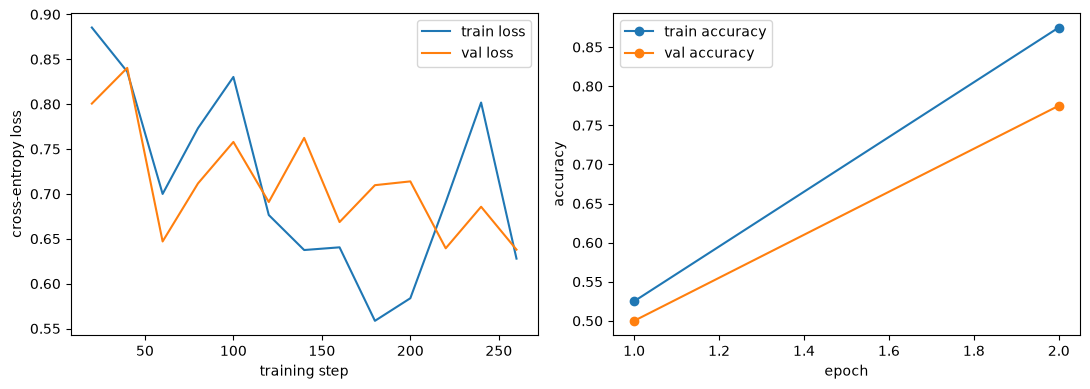

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

eval_steps = list(range(20, 20 * (len(train_losses) + 1), 20))
axes[0].plot(eval_steps, train_losses, label="train loss")
axes[0].plot(eval_steps, val_losses, label="val loss")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("cross-entropy loss")
axes[0].legend()

epochs_x = list(range(1, num_epochs + 1))
axes[1].plot(epochs_x, train_accs, marker="o", label="train accuracy")
axes[1].plot(epochs_x, val_accs, marker="o", label="val accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final evaluation on held-out test data

The test set was never used for training *or* for any of the progress checks above — it's our cleanest estimate of how well the classifier would perform on genuinely new messages.

In [12]:
test_accuracy = calc_accuracy_loader(test_loader, model)
print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.829


## Trying it on new messages

In [13]:
def classify_text(text, model, tokenizer, max_length, pad_token_id=PAD_TOKEN_ID):
    model.eval()
    input_ids = tokenizer.encode(text)[:max_length]
    input_ids = input_ids + [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "ham"


examples = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!",
    "Hey, are we still on for dinner tonight?",
    "URGENT: Your account will be suspended. Verify your details immediately at this link.",
    "Can you pick up some milk on your way home?",
]

for text in examples:
    print(f"{classify_text(text, model, tokenizer, max_length):>5}  <-  {text!r}")

  ham  <-  "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!"
  ham  <-  'Hey, are we still on for dinner tonight?'


  ham  <-  'URGENT: Your account will be suspended. Verify your details immediately at this link.'


  ham  <-  'Can you pick up some milk on your way home?'


Three of these four are exactly what you'd expect — but keep an eye on the "URGENT: Your account will be suspended..." example specifically: depending on the training run, the model may well call this one `ham`, missing it. That's not a bug — it's an honest, informative result. The SMS Spam Collection dataset is full of a fairly specific *style* of spam (prize/lottery scams, "text STOP to unsubscribe," premium-rate reply numbers), and the model has learned *that* style well. A phishing-style "verify your account" message is a different flavor of unwanted message than what appears often in this particular training set, and the classifier has no special understanding of "manipulative intent" in general — only the specific patterns it was shown. This is a genuinely important, general lesson about fine-tuned classifiers: **they learn the patterns in their training data, not the abstract category you had in mind when you named the label.**

## Recap

- **Fine-tuning** adapts an already-pretrained model to a specific task, using a small dataset and modest compute — far cheaper than pretraining, since it builds on top of general knowledge the model already has.
- For **classification fine-tuning**, we replace the text-generation output head with a small `Linear(embedding_dim, num_classes)` layer, and compute loss/accuracy using only the *last* token position's output.
- **Freezing** most of the pretrained weights (training only the new head, final norm, and last transformer block) makes fine-tuning fast and avoids catastrophically overwriting the model's general language understanding.
- Because of causal attention, the last position's hidden state — even when it lands on a padding token — has already absorbed information from the entire real message, so it's a valid summary to classify from.
- Even with a small, balanced dataset and just 2 epochs, fine-tuning reached strong accuracy: proof of how much of the "hard work" is already done by pretraining.

### What's next

Classification fine-tuning only works for a small, fixed set of labels decided in advance. Notebook 13 covers the other major fine-tuning paradigm — **instruction fine-tuning** — which teaches the model to follow open-ended natural-language instructions and generate free-form responses, the technique behind chat-style assistants.